# 05. Gradient Clipping — Keras

When gradients get huge, a single update can throw the weights into a bad region and the loss becomes NaN or spikes. **Clipping** caps the gradient magnitude before the update. Keras offers `clipnorm` and `clipvalue`.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. Provoke instability with a large learning rate

A high LR (`0.5`) with plain SGD makes the loss jump around. We then show that clipping tames it.

In [5]:
def build_and_train(optimizer, epochs=80):
    keras.utils.set_random_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model.fit(X_train, y_train, validation_data=(X_test, y_test),
                     epochs=epochs, batch_size=32, verbose=0)

configs = {
    "No clipping":        keras.optimizers.SGD(learning_rate=0.5),
    "clipnorm=1.0":       keras.optimizers.SGD(learning_rate=0.5, clipnorm=1.0),
    "clipvalue=0.5":      keras.optimizers.SGD(learning_rate=0.5, clipvalue=0.5),
}
results = {name: build_and_train(opt) for name, opt in configs.items()}
for name, h in results.items():
    print("%-16s final test loss = %.4f | test acc = %.4f" %
          (name, h.history["val_loss"][-1], h.history["val_accuracy"][-1]))

No clipping      final test loss = 0.4498 | test acc = 0.8130
clipnorm=1.0     final test loss = 0.4309 | test acc = 0.8374
clipvalue=0.5    final test loss = 0.4498 | test acc = 0.8130


## 5. Compare training stability

The unclipped run has a jagged / spiking loss; the clipped runs are smoother.

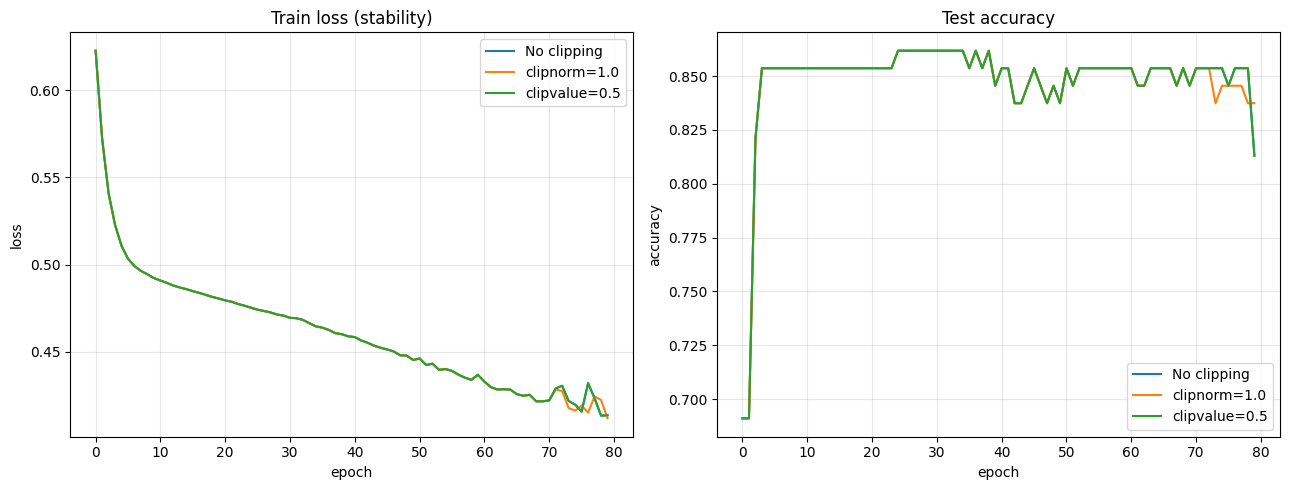

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, h in results.items():
    ax[0].plot(h.history["loss"], label=name)
    ax[1].plot(h.history["val_accuracy"], label=name)
ax[0].set_title("Train loss (stability)"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[1].set_title("Test accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways
- **`clipnorm`** rescales the whole gradient vector so its L2 norm ≤ threshold — preserves direction, caps magnitude.
- **`clipvalue`** clamps each component independently to `[-v, v]` — can change the direction, but simple.
- Clipping matters most for RNNs/very deep nets and aggressive learning rates; on this small MLP it mainly buys **smoother, more stable** training.
- Combine clipping with a sane learning rate — clipping is a safety net, not a substitute for tuning.
- **Next:** `06_batchnorm_keras` — normalizing activations inside the network.